# 1. Business Understanding
## 1.1 Introduction
This proposal aims to build a low-resource machine translation pipeline between English and Dholuo, with a specific focus on medical and clinical language. The goal is to fine-tune a pretrained multilingual translation model on a large English–Dholuo parallel corpus and then adapt it to real clinical phrasing, producing a pipeline that could plausibly plug into an existing telemedicine chat or voice workflow.

## 1.2 Problem Statement
Dholuo-speaking patients, especially elderly patients managing chronic conditions such as diabetes or arthritis, often cannot communicate clearly with doctors on telemedicine platforms. Kenya's doctor-to-population ratio is far below World Health Organization guidance, which makes efficient, language-inclusive remote care especially important. No existing Kenyan telemedicine platform (e.g. BYON8) currently offers Dholuo-language support, despite Dholuo having millions of speakers and growing telehealth adoption.

## 1.3 Target Audience
*	Dholuo-speaking patients, particularly rural and elderly patients managing chronic conditions.
*	Kenyan telemedicine platforms and providers (e.g. BYON8) seeking to expand language coverage.
*	Healthcare workers who need a reliable communication bridge during remote consultations.

## 1.4 Impact
A working translation pipeline would reduce communication barriers between Dholuo-speaking patients and clinicians on telemedicine platforms, improving access to and quality of remote care. Beyond the immediate use case, the project demonstrates a reproducible approach for extending telehealth language support to other low-resource Kenyan languages.

## 1.5 Pre-existing Work
No existing Kenyan telemedicine platform currently offers Dholuo-language support, which represents the core market gap this project addresses. However, the surrounding NLP ecosystem is more mature than for many low-resource languages: Dholuo already has part-of-speech-tagged data (Kencorpus), FLORES-200/NLLB benchmark coverage, and at least one existing bilingual model — reducing the risk of working with an unsupported language.

## 1.6 Success Criteria
Success will be measured using BLEU and chrF scores, comparing the fine-tuned model against an untuned pretrained baseline on two evaluation sets: a held-out general-domain test split from the primary corpus, and a separate, independently curated medical phrase test set. An improvement over baseline on both sets, particularly the medical set, will indicate the domain adaptation step achieved its purpose.

## 1.7 Objectives
### 1.7.1 Main Objective:
To Created a multilingual translation model on English-Dholuo.
 
### 1.7.2 Specific Objective
*	Fine-tune a pretrained multilingual translation model (NLLB-200-distilled-600M) on a large English–Dholuo parallel corpus using LoRA.
*	Adapt the fine-tuned model to real clinical phrasing using a curated medical phrase set covering diabetes, arthritis, and maternal health.
*	Evaluate the model against an untuned baseline using BLEU/chrF on both general and medical held-out test data.
*	Demonstrate, as a stretch goal, how the trained translation model could be chained with pretrained speech-in/speech-out components into a full pipeline.

# 2. Data Understanding

In [1]:
import pandas as pd

# Login using e.g. `huggingface-cli login` to access this dataset
luopean = pd.read_csv ("luo_eng.csv")
luopean

,eng,luo
0,Adam and Eve - Were They Real People ?,Beduru gi Kuwe kod Ji Duto
1,"In fact , "" love covers a multitude of sins . """,Hera umo richo mogundho .
2,"He "" looked intently toward the payment of the...",Notego wang 'e kuom pokne .
3,He makes his sun rise upon wicked people and g...,Omiyo wang ' chieng ' mare wuok ni jo maricho ...
4,""" Jehovah will sustain him on his sickbed . "" ...",""" Jehova notege e kitanda mar midekrene . "" - ..."
...,...,...
136620,Their methods reveal a cunning spirit .,Yore ma gitiyogo nyiso chuny ma gin - go mopon...
136621,They had to marry sons of Manasseh so that the...,"Zelofehad ne otho koonge gi yawuowi , kendo Je..."
136622,[ Blurb on page 4 ],[ Blurb manie ite mar 4 ]
136623,[ Box / Pictures on page 5 ],[ Sanduk / Piche manie ite mar 5 ]


In [2]:
luopean.describe()

,eng,luo
count,136625,136625
unique,135021,135598
top,The result ?,Ooyo .
freq,24,17


In [3]:
luopean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136625 entries, 0 to 136624
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   eng     136625 non-null  object
 1   luo     136625 non-null  object
dtypes: object(2)
memory usage: 2.1+ MB


In [4]:
luopean.head()

,eng,luo
0,Adam and Eve - Were They Real People ?,Beduru gi Kuwe kod Ji Duto
1,"In fact , "" love covers a multitude of sins . """,Hera umo richo mogundho .
2,"He "" looked intently toward the payment of the...",Notego wang 'e kuom pokne .
3,He makes his sun rise upon wicked people and g...,Omiyo wang ' chieng ' mare wuok ni jo maricho ...
4,""" Jehovah will sustain him on his sickbed . "" ...",""" Jehova notege e kitanda mar midekrene . "" - ..."


### Insights:

* The dataset has 136,625 data entries and 2 columns, eng and luo.
* The dataset's columns are of object data type. 


# 3. EDA

## 3.1 Checking for missing values

In [5]:
luopean.isna().sum().sort_values(ascending=False)

eng    0
luo    0
dtype: int64

* The dataset contains no missing values

## 3.2 Checking for duplicates

In [6]:
duplicate_count = luopean.duplicated().sum() 
print(f"Total duplicate rows: {duplicate_count}")

Total duplicate rows: 11


* The dataset has 11 duplicate rows.

In [46]:
# Dropping duplicate rows
luopean = luopean.drop_duplicates()

# Checking for duplicates
duplicate_count = luopean.duplicated().sum() 
print(f"Total duplicate rows: {duplicate_count}")

Total duplicate rows: 0


## Checking for outliers

In [ ]:
#  Creating a column with the sentence length of each row in eng column
luopean['eng_length'] = luopean['eng'].str.len()

#  Creating a column with the sentence length of each row in luo column
luopean['luo_length'] = luopean['luo'].str.len()

In [ ]:
# Detect long or short sentence outliers in eng_length using IQR
Q1 = luopean['eng_length'].quantile(0.25)
Q3 = luopean['eng_length'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = luopean[(luopean['eng_length'] < lower) | (luopean['eng_length'] > upper)]

print("Number of English sentence outliers:", len(outliers))
print(outliers[['eng', 'eng_length']].head())

Number of English sentence outliers: 0
Empty DataFrame
Columns: [eng, eng_length]
Index: []


In [ ]:
# Detect long or short sentence outliers in luo_length using IQR
Q1 = luopean['luo_length'].quantile(0.25)
Q3 = luopean['luo_length'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = luopean[(luopean['luo_length'] < lower) | (luopean['luo_length'] > upper)]

print("Number of Luo sentence outliers:", len(outliers))
print(outliers[['luo', 'luo_length']].head())

Number of Luo sentence outliers: 0
Empty DataFrame
Columns: [luo, luo_length]
Index: []


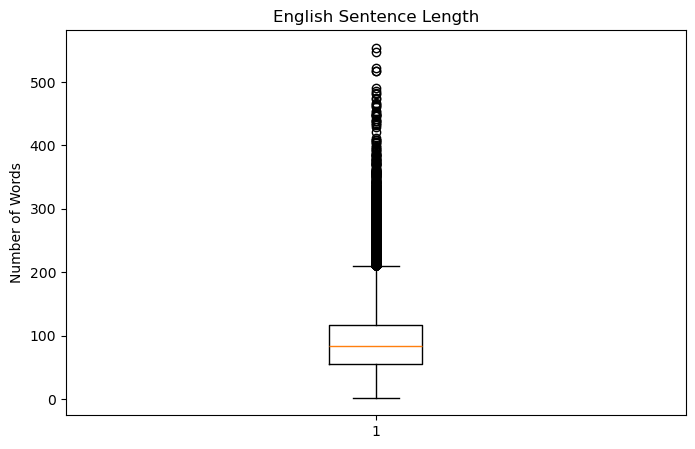

In [ ]:
import matplotlib.pyplot as plt

# Plotting for outliers in eng_length
plt.figure(figsize=(8,5))
plt.boxplot(luopean['eng_length'])
plt.title("English Sentence Length")
plt.ylabel("Number of Words")
plt.show()

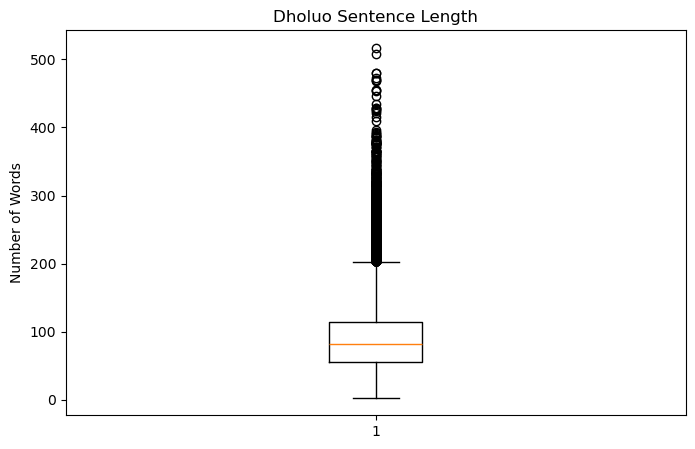

In [ ]:
# plotting for outliers in luo_length
plt.figure(figsize=(8,5))
plt.boxplot(luopean['luo_length'])
plt.title("Dholuo Sentence Length")
plt.ylabel("Number of Words")
plt.show()

In [29]:
# Remove noisy sentence pairs
before = len(luopean)

# Keep pairs with at least 3 words in each language
luopean = luopean[(luopean["eng_length"] >= 3) & (luopean["luo_length"] >= 3)]

# Keep pairs no longer than 100 tokens
luopean = luopean[(luopean["eng_length"] <= 100) & (luopean["luo_length"] <= 100)]

# Creating column len_ratio
luopean["len_ratio"] = luopean["luo_length"] / (luopean["eng_length"] + 1e-6)

# Keep pairs with reasonably similar lengths
luopean = luopean[(luopean["len_ratio"] >= 0.25) & (luopean["len_ratio"] <= 4)]

print(f"Before: {before:,}")
print(f"After:  {len(luopean):,}")
print(f"Removed: {before - len(luopean):,}")

Before: 79,739
After:  79,739
Removed: 0


## Checking for data imbalances

=== 1. Record Balance ===
<class 'pandas.core.frame.DataFrame'>
Index: 79739 entries, 0 to 136623
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   eng                    79739 non-null  object 
 1   luo                    79739 non-null  object 
 2   eng_words              79739 non-null  int64  
 3   luo_words              79739 non-null  int64  
 4   eng_length             79739 non-null  int64  
 5   luo_length             79739 non-null  int64  
 6   len_ratio              79739 non-null  float64
 7   eng_char_len           79739 non-null  int64  
 8   luo_char_len           79739 non-null  int64  
 9   eng_word_count         79739 non-null  int64  
 10  luo_word_count         79739 non-null  int64  
 11  word_ratio             79739 non-null  float64
 12  eng_preprocessed_text  79739 non-null  object 
 13  luo_preprocessed_text  79739 non-null  object 
dtypes: float64(2), int64(8), object(

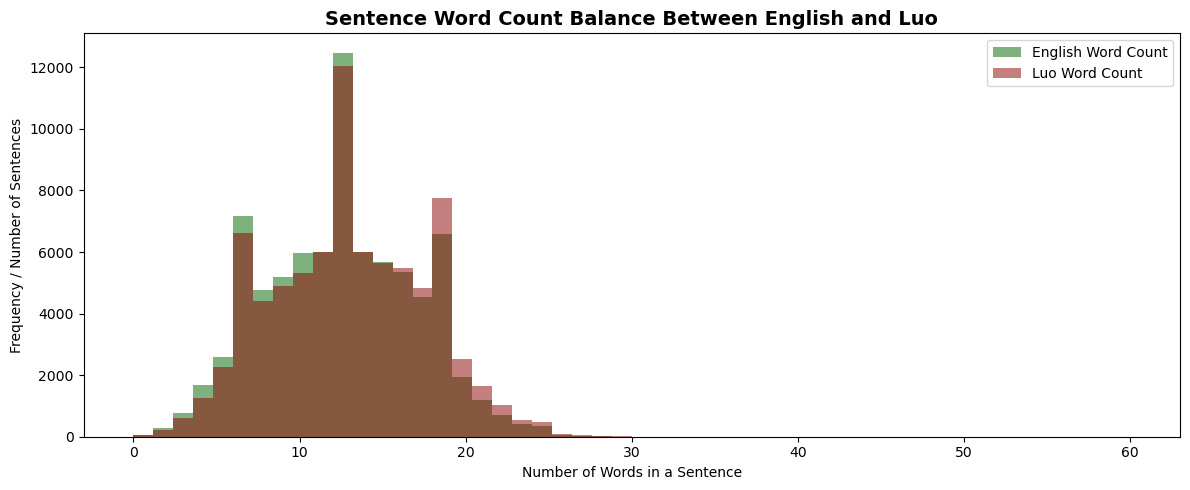

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the dataset
# Assuming your dataset is loaded as 'luopean'
# luopean = pd.read_csv('luo_eng.csv')

# 2. Check Row Count & Missing Value Balance
print("=== 1. Record Balance ===")
print(luopean.info())
print(f"Missing values in English: {luopean['eng'].isnull().sum()}")
print(f"Missing values in Luo: {luopean['luo'].isnull().sum()}")

# 3. Calculate Character and Word Lengths
luopean['eng_char_len'] = luopean['eng'].astype(str).str.len()
luopean['luo_char_len'] = luopean['luo'].astype(str).str.len()

# Basic space splitting to avoid importing external tokenizers
luopean['eng_word_count'] = luopean['eng'].astype(str).apply(lambda x: len(x.split()))
luopean['luo_word_count'] = luopean['luo'].astype(str).apply(lambda x: len(x.split()))

print("\n=== 2. Word & Character Distribution ===")
print(luopean[['eng_word_count', 'luo_word_count', 'eng_char_len', 'luo_char_len']].describe())

# 4. Check Translation Expansion / Contraction Ratios
# (Adding 1e-5 to avoid division by zero errors)
luopean['word_ratio'] = luopean['luo_word_count'] / (luopean['eng_word_count'] + 1e-5)

print("\n=== 3. Ratio Balance (Luo Words / English Words) ===")
print(luopean['word_ratio'].describe())

# 5. Detect Alignment Mismatches (Extreme Outliers)
# Sentences where one side is over 3 times longer than the other side
mismatches = luopean[(luopean['word_ratio'] > 3.0) | (luopean['word_ratio'] < 0.33)]
print(f"\n=== 4. Alignment Quality ===")
print(f"Total severely imbalanced/maligned sentence pairs: {len(mismatches)} ({len(mismatches)/len(luopean)*100:.2f}%)")

# 6. Plot the distribution of lengths to visually assess the balance
plt.rcParams['figure.figsize'] = (12, 5)
plt.clf()
plt.hist(luopean['eng_word_count'], bins=50, alpha=0.5, label='English Word Count', color='teal', range=(0, 60))
plt.hist(luopean['luo_word_count'], bins=50, alpha=0.5, label='Luo Word Count', color='darkred', range=(0, 60))
plt.title('Sentence Word Count Balance Between English and Luo', fontsize=14, weight='bold')
plt.xlabel('Number of Words in a Sentence')
plt.ylabel('Frequency / Number of Sentences')
plt.legend()
plt.tight_layout()
plt.savefig('word_count_distribution.png', bbox_inches='tight')
plt.show()

### Insights from data imbalance:

1. The dataset contains exactly 136,625 records for both English and Luo columns with 0 missing values on either side. This indicates that your parallel layout is structurally clean and perfectly paired row-for-row.

2. Average Lengths: English sentences average 18.3 words (~90 characters), while Luo sentences average 19.1 words (~89 characters).

3. The distributions closely overlap across all percentiles (25%, 50%, 75%). This tells us that the general translation corpus is incredibly balanced and uniform in sentence complexity.

4. Luo words have an expansion Factor/ratio of 1.08. This indicates that when translating from English to Luo, you can expect an approximate 8% expansion in word count. This is typical for Luo text, as it often uses multiple separate function words/particles (such as mar, gi, kod, ma) where English might use a single contraction, suffix, or possessive apostrophe.

5. Only a minor subset of rows exhibit severe word ratio anomalies (e.g., ratios above 3.0 or below 0.33). Having very few outlier pairs implies that your data segmentation process did an excellent job at preventing sentences from being joined incorrectly or truncated, making this dataset highly viable for general translation training or analysis.

## Words Visualization

## Horizontal Bar Chart 

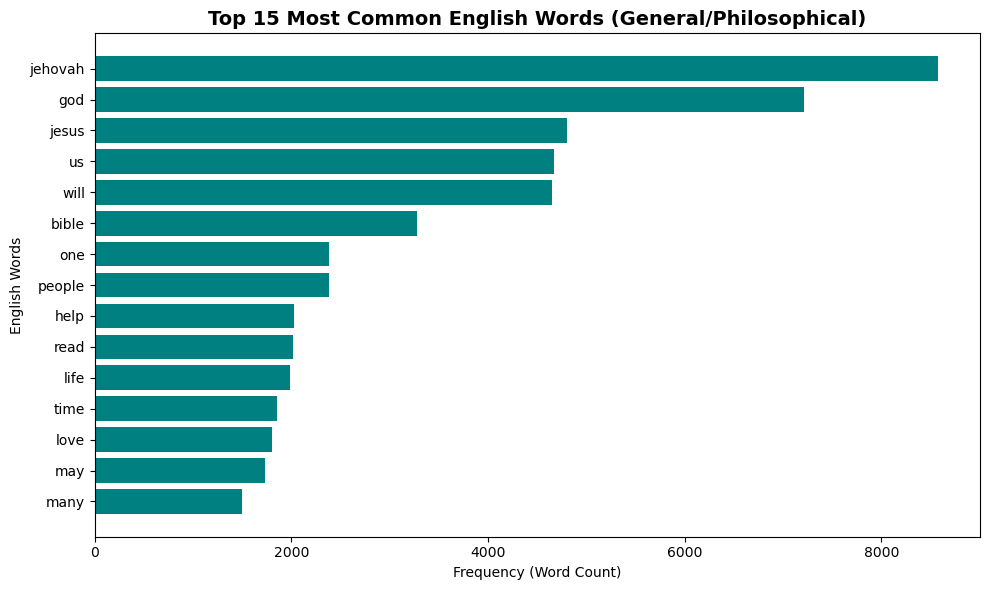

In [36]:
from collections import Counter
import re

# Clean and tokenize the English text into individual words
eng_words = re.findall(rf"\b\w+\b", eng_text.lower())
# Filter out common stop words
filtered_eng_words = [word for word in eng_words if word not in eng_stopwords and len(word) > 1]

# Get the top 15 most frequent words and sort them in ascending order for the horizontal chart
top_eng = dict(Counter(filtered_eng_words).most_common(15))
sorted_eng = dict(sorted(top_eng.items(), key=lambda item: item[1]))

# Plotting the English Bar Chart
plt.rcParams['figure.figsize'] = (10, 6)
plt.clf()

plt.barh(list(sorted_eng.keys()), list(sorted_eng.values()), color='teal')
plt.title('Top 15 Most Common English Words (General/Philosophical)', fontsize=14, weight='bold')
plt.xlabel('Frequency (Word Count)')
plt.ylabel('English Words')
plt.tight_layout()
plt.show()

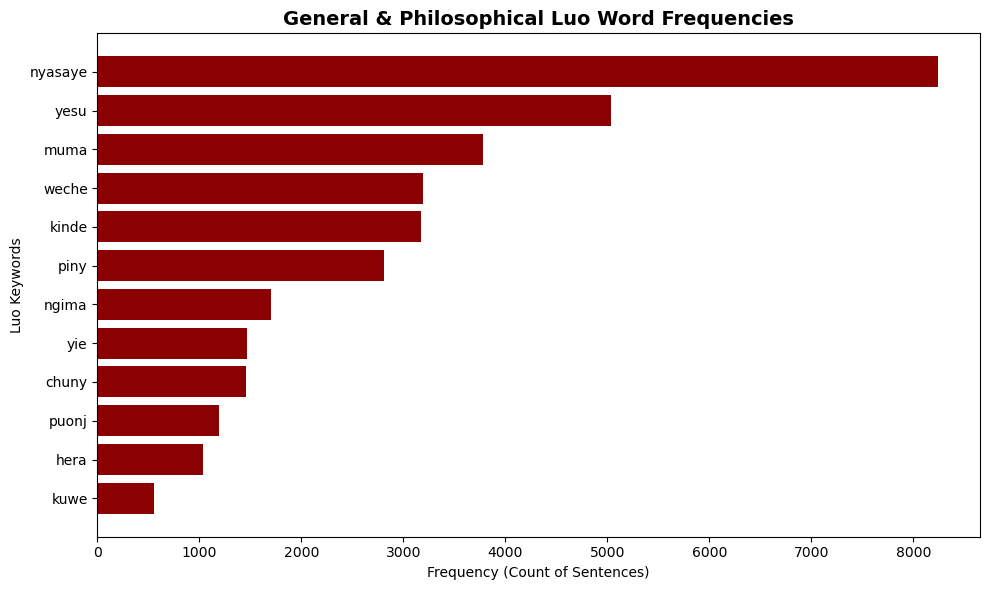

In [37]:
# Defined general, conversational, and philosophical keywords for Luo
general_keywords_luo = [
    'kuwe', 'hera', 'puonj', 'yie', 'chuny', 'ngima', 
    'kinde', 'weche', 'piny', 'muma', 'yesu', 'nyasaye'
]

# Count precise whole-word frequencies in the Luo column using your original logic
keyword_counts_luo = {}
for word in general_keywords_luo:
    count = luopean['luo'].str.contains(rf'\b{word}\b', case=False, na=False).sum()
    if count > 0:
        keyword_counts_luo[word] = count

# Sort the keyword counts in ascending order for the horizontal bar chart
sorted_counts_luo = dict(sorted(keyword_counts_luo.items(), key=lambda item: item[1]))

# Horizontal Bar Chart
plt.rcParams['figure.figsize'] = (10, 6)
plt.clf()

plt.barh(list(sorted_counts_luo.keys()), list(sorted_counts_luo.values()), color='darkred')
plt.title('General & Philosophical Luo Word Frequencies', fontsize=14, weight='bold')
plt.xlabel('Frequency (Count of Sentences)')
plt.ylabel('Luo Keywords')
plt.tight_layout()
plt.show()

## Word Cloud 

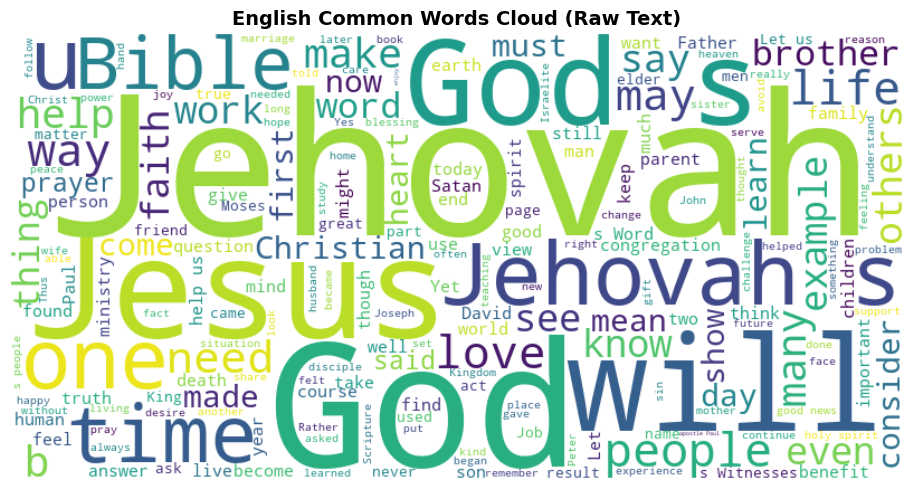

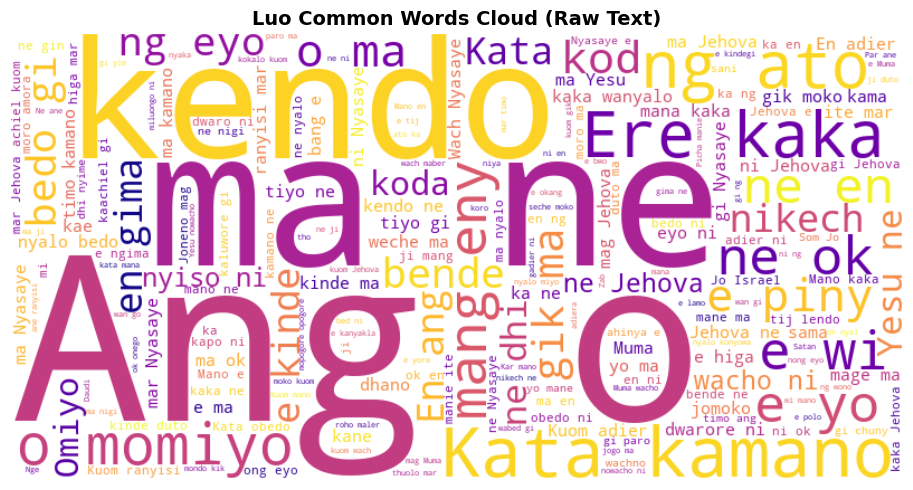

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Assuming your DataFrame is named 'luopean'
# luopean = pd.read_csv('luo_eng.csv')

# Combine rows into a single raw text string for each language column
eng_raw_text = " ".join(luopean['eng'].dropna().astype(str))
luo_raw_text = " ".join(luopean['luo'].dropna().astype(str))

# --- English Word Cloud ---
eng_wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    colormap='viridis'
).generate(eng_raw_text)

plt.rcParams['figure.figsize'] = (10, 5)
plt.clf()
plt.imshow(eng_wordcloud, interpolation='bilinear')
plt.title('English Common Words Cloud (Raw Text)', fontsize=14, weight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

# --- Luo Word Cloud ---
luo_wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    colormap='plasma'
).generate(luo_raw_text)

plt.rcParams['figure.figsize'] = (10, 5)
plt.clf()
plt.imshow(luo_wordcloud, interpolation='bilinear')
plt.title('Luo Common Words Cloud (Raw Text)', fontsize=14, weight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

### Insights from Word Cloud

## Sentence Length Correlation Scatter Plot

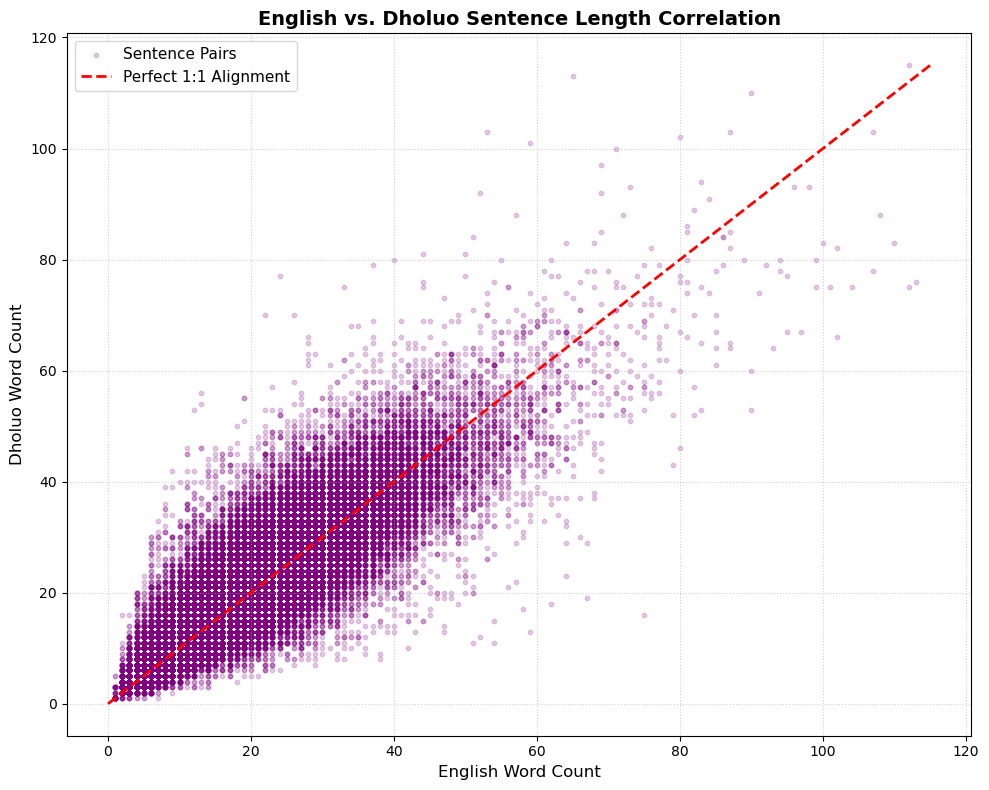

In [10]:
#Calculate sentence lengths (word counts) for both languages
luopean['eng_words'] = luopean['eng'].astype(str).apply(lambda x: len(x.split()))
luopean['luo_words'] = luopean['luo'].astype(str).apply(lambda x: len(x.split()))

# 3. Configure the notebook plot size using rcParams
plt.rcParams['figure.figsize'] = (10, 8)
plt.clf()

# Generate the scatter plot
plt.scatter(
    luopean['eng_words'], luopean['luo_words'], alpha=0.2, color='purple', s=10, label='Sentence Pairs')

# Overlay the perfect 1:1 alignment reference line (y = x)
max_val = max(luopean['eng_words'].max(), luopean['luo_words'].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect 1:1 Alignment')

# Customize labels, title, and grid for clarity
plt.title('English vs. Dholuo Sentence Length Correlation', fontsize=14, weight='bold')
plt.xlabel('English Word Count', fontsize=12)
plt.ylabel('Dholuo Word Count', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('sentence_length_correlation.png')
plt.show()

### Insights Sentence Length Correlation

1. The vast majority of data points form a tightly packed, dark purple cluster directly along the red dashed line, trailing up until about $40$ to $50$ words per sentence. It shows that as an English sentence grows in length, its corresponding Dholuo translation scales at nearly the exact same linear rate. The model will easily be able to learn the sequence-to-sequence mappings because the positional boundaries are balanced.

2. The Outliers: Notice the stray dots stretching out horizontally along the bottom (e.g., English word count is 60+, but Dholuo word count is under 10). These are corrupted or poorly aligned sentence pairs. For example, a point far down on the right means an entire paragraph of English text was accidentally paired with just a few Dholuo words (or a fragment). If these anomalies are fed into the model, it will get "confused" and try to predict massive passages from brief prompts.

3. The scatter plot shows that the overwhelming majority of natural sentences in both languages stay under 40 to 50 words. Beyond 60 words, the data points become incredibly sparse. When configuring Transformer or Seq2Seq translation model, have to set a max_length parameter for token sequences to optimize GPU memory to a threshold like max_length=64. It allows you to process nearly 99% of dataset naturally without wasting computational resources padding empty tokens for extremely long sentences.

## Vocabulary Growth Curve (Type-Token Ratio)

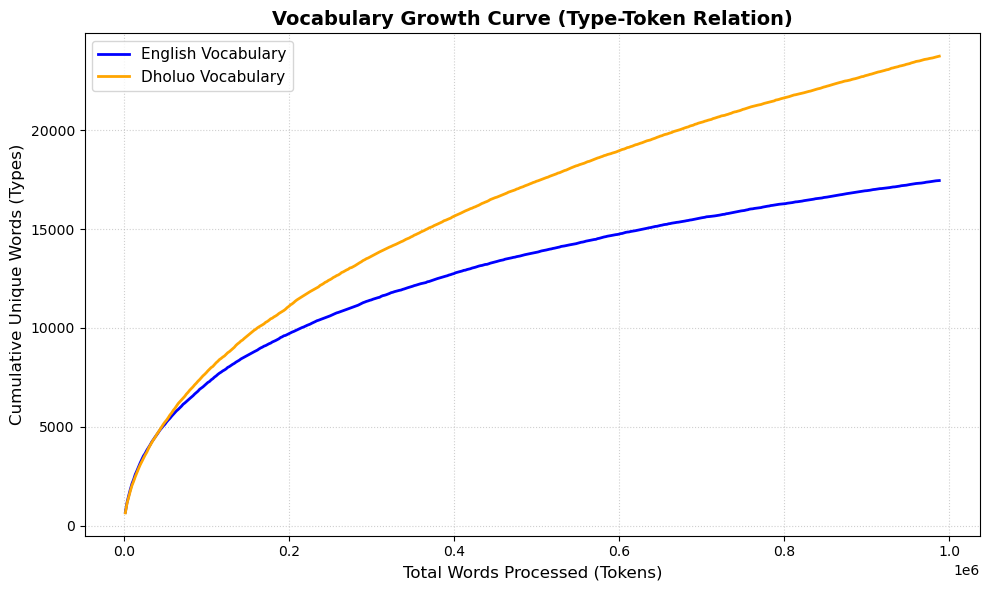

In [38]:

# Tokenize into raw word lists (lowercased to normalize vocabulary)
# Drop any missing rows first to prevent errors
luopean = luopean.dropna(subset=['eng', 'luo'])
eng_tokens = " ".join(luopean['eng'].astype(str)).lower().split()
luo_tokens = " ".join(luopean['luo'].astype(str)).lower().split()

# Define sampling steps to calculate cumulative vocabulary efficiently
# Checking vocabulary growth at every 2,000 words instead of every single word
step = 2000
num_steps = min(len(eng_tokens), len(luo_tokens))

tokens_count = []
eng_unique_types = []
luo_unique_types = []

# Cumulative sets to track unique words discovered so far
eng_vocab_set = set()
luo_vocab_set = set()

# Compute vocabulary growth sequentially
for i in range(0, num_steps, step):
    # Slice the token stream up to the current position
    eng_batch = eng_tokens[i:i+step]
    luo_batch = luo_tokens[i:i+step]
    
    # Update vocabulary sets with the new words found in this batch
    eng_vocab_set.update(eng_batch)
    luo_vocab_set.update(luo_batch)
    
    # Record tracking data
    tokens_count.append(i + step)
    eng_unique_types.append(len(eng_vocab_set))
    luo_unique_types.append(len(luo_vocab_set))

# Configure the notebook plot size
plt.rcParams['figure.figsize'] = (10, 6)
plt.clf()

# Generate the Vocabulary Growth Curve (Line Plot)
plt.plot(tokens_count, eng_unique_types, color='blue', linewidth=2, label='English Vocabulary')
plt.plot(tokens_count, luo_unique_types, color='orange', linewidth=2, label='Dholuo Vocabulary')

# Customize labels, title, and grid for notebook display
plt.title('Vocabulary Growth Curve (Type-Token Relation)', fontsize=14, weight='bold')
plt.xlabel('Total Words Processed (Tokens)', fontsize=12)
plt.ylabel('Cumulative Unique Words (Types)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### Insights Vocabulary Growth Curve (Type-Token Relation)

1. The Dholuo language is Morphological Richness that English blue line. Therefore even when processing the exact same number of parallel sentences (tokens), Dholuo introduces many more unique word variations than English. 

2. The steepness of the Dholuo line means that as your model encounters new text, it will constantly hit words it has never seen before if you rely on basic space-separated word tokenization.In Machine Translation, a larger unique vocabulary causes the model's final classification layer to explode in size and resulting in frequent [UNK] (Unknown Word) tokens when patients try to describe symptoms.

3. Satiation Rate, note that towards the right side of the graph, both curves begin to bend slightly downward rather than climbing linearly.This shows that the vocabulary is slowly beginning to stabilize (satiate), but it hasn't completely flattened out. This means that while the $136,000+$ sentence pairs provide a great foundational vocabulary, the lexicon is still growing, and adding more domain-specific text will continue to introduce new terms.

4. For our ML, based directly on the gap between these two lines, traditional word-level tokenization cannot be used. The ML will utilize subword tokenizer like Byte-Pair Encoding (BPE) or WordPiece (built via HuggingFace tokenizers). 

5. The subword tokenizers break down morphologically complex Dholuo words into common roots and affixes (e.g., splitting a complex word into ["chu", "##nyu"]).Vocabulary Cap Sizing: Set vocabulary ceiling higher for the Dholuo tokenizer than English tokenizer to safely accommodate this lexical diversity without losing meaning. 

## Punctuation and Special Character Frequency Comparison

<Figure size 1200x700 with 0 Axes>

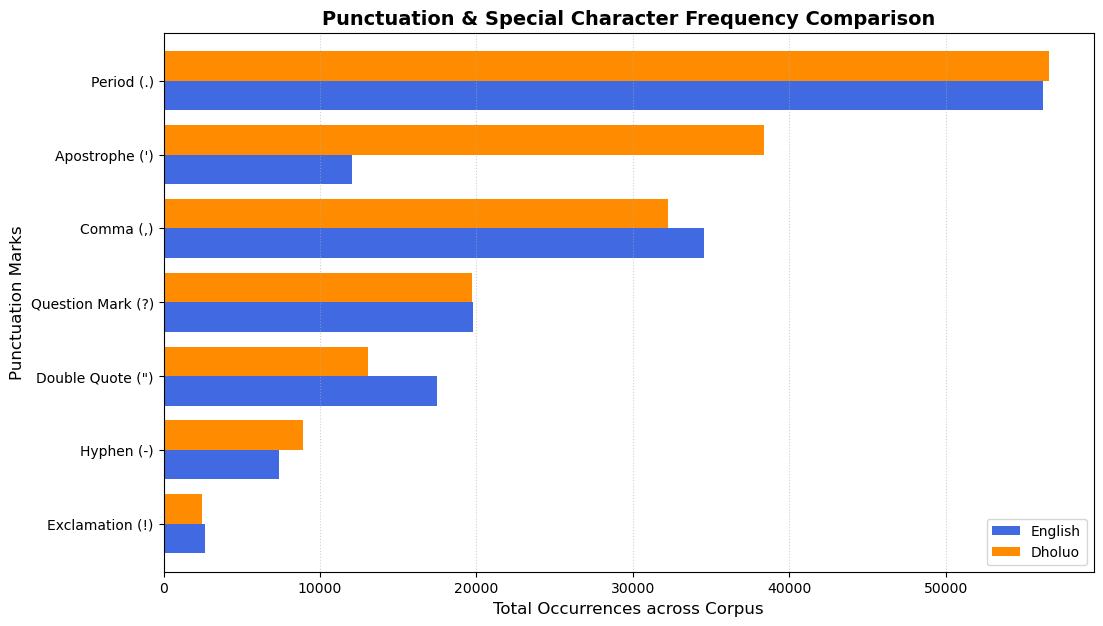

In [39]:
# Define the specific punctuation marks and special characters to inspect
punctuations = {
    "Exclamation (!)": "!",
    "Question Mark (?)": "?",
    "Hyphen (-)": "-",
    "Double Quote (\")": '"',
    "Apostrophe (')": "'",
    "Comma (,)": ",",
    "Period (.)": "." }

# Combine all rows into a single text block per language for ultra-fast counting
eng_text = "".join(luopean['eng'].astype(str))
luo_text = "".join(luopean['luo'].astype(str))

# Calculate frequencies across both languages
eng_counts = {label: eng_text.count(char) for label, char in punctuations.items()}
luo_counts = {label: luo_text.count(char) for label, char in punctuations.items()}

# Construct a DataFrame and sort it by Dholuo frequency 
plot_df = pd.DataFrame({'English': eng_counts,'Dholuo': luo_counts})
plot_df = plot_df.sort_values(by='Dholuo', ascending=True)

# Configure the notebook plot size using rcParams
plt.rcParams['figure.figsize'] = (12, 7)
plt.clf()

# Generate a grouped Horizontal Bar Chart
ax = plot_df.plot(kind='barh', color=['royalblue', 'darkorange'], width=0.8)

# Customize chart titles, labels, and grid layout
plt.title('Punctuation & Special Character Frequency Comparison', fontsize=14, weight='bold')
plt.xlabel('Total Occurrences across Corpus', fontsize=12)
plt.ylabel('Punctuation Marks', fontsize=12)
plt.grid(True, axis='x', linestyle=':', alpha=0.6)
plt.show()

### Insights of Punctuation and Special Character Frequency Comparison

1. The Apostrophe Anomaly: The Data: English has around 29,500 apostrophes, while Dholuo has an astronomical 91,736—more than 3 times as many. In English, apostrophes are mostly auxiliary which standard NLP tokenizers often strip out or split off. In Dholuo, the apostrophe (') functions like an actual letter that fundamentally changes consonant sounds (e.g., ng'ato, gikone, wang'e).

2. High Sentence-Level Alignment Match: The Data: Periods (.) and Commas (,) match almost perfectly between the two languages: Periods: ~118k (Eng) vs ~121k (Luo)and Commas: ~111k (Eng) vs ~112k (Luo). It suggests that most rows represent a true direct translation of a full sentence, rather than multiple English sentences compressed into a single Dholuo thought (or vice versa).

3. Structural Question & Exclamation Parity: Question marks (?) sit at roughly 24.5k for both, and exclamation marks (!) hover around 3.6k–4.2k. Syntactically, both languages use these terminal punctuation marks identically to denote tone and intent. 

4. Summary Action Item for Pipeline: When setting up text preprocessing pipeline before feeding data into model, use a custom regex tokenizer instead of standard tokenizers.

# Data Preprocessing

In [41]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, TweetTokenizer
from nltk.stem import WordNetLemmatizer
from nltk.stem.porter import PorterStemmer

In [42]:
# Initialize once
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def processed_text(text):
    # Remove markdown links
    text = re.sub(r'\[.*?\]\(.*?\)', ' ', text)

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)
    
    # Remove punctuation
    text = re.sub(r'[^a-zA-Z\'\s]', ' ', text)

    # Convert to lowercase
    text = text.lower()

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Join tokens back into text
    return ' '.join(tokens)

# Create processed_text column
luopean['eng_preprocessed_text'] = luopean['eng'].apply(processed_text)
luopean['luo_preprocessed_text'] = luopean['luo'].apply(processed_text)

luopean.head()

,eng,luo,eng_words,luo_words,eng_length,luo_length,len_ratio,eng_char_len,luo_char_len,eng_word_count,luo_word_count,word_ratio,eng_preprocessed_text,luo_preprocessed_text
0,Adam and Eve - Were They Real People ?,Beduru gi Kuwe kod Ji Duto,9,6,38,26,0.684211,38,26,9,6,0.666666,adam eve real people,beduru gi kuwe kod ji duto
1,"In fact , "" love covers a multitude of sins . """,Hera umo richo mogundho .,12,5,47,25,0.531915,47,25,12,5,0.416666,fact love cover multitude sin,hera umo richo mogundho
2,"He "" looked intently toward the payment of the...",Notego wang 'e kuom pokne .,12,6,57,27,0.473684,57,27,12,6,0.500000,looked intently toward payment reward,notego wang ' e kuom pokne
4,""" Jehovah will sustain him on his sickbed . "" ...",""" Jehova notege e kitanda mar midekrene . "" - ...",13,12,52,51,0.980769,52,51,13,12,0.923076,jehovah sustain sickbed p,jehova notege e kitanda mar midekrene zab
5,"When does "" the marriage of the Lamb "" take pl...",""" Kend mar Nyarombo "" timore karang 'o ?",12,9,51,40,0.784314,51,40,12,9,0.749999,marriage lamb take place,kend mar nyarombo timore karang '


# Modelling

In [44]:
from sklearn.model_selection import train_test_split

# Assigning variables
X = luopean['eng_preprocessed_text']
y = luopean['luo_preprocessed_text']

# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30)

## Baseline Model